<p align="center">
  <img src="assets/IMG1.png" width="100%" alt="Diabetes Risk Classification Project Banner">
</p>

# Diabetes Risk Classification Using Machine Learning

<p align="center">
  An end-to-end machine learning classification project using clinical features,
  data-quality-aware preprocessing, cross-validation and model evaluation.
</p>

---

## Project Overview

The objective of this project is to build and evaluate machine learning models
that classify whether a patient belongs to the diabetes-positive or
diabetes-negative outcome group based on clinical measurements.

The project focuses not only on model accuracy, but also on:

- identifying hidden data-quality problems,
- preventing data leakage,
- building reusable preprocessing pipelines,
- comparing models using stratified cross-validation,
- evaluating positive-class performance,
- and interpreting the final model.

> **Medical disclaimer:** This project is intended only for educational and
> portfolio purposes. It is not a medical diagnostic system and must not be
> used for clinical decision-making.

## Technologies Used

- Python
- NumPy
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn
- OpenML
- Jupyter Notebook

## Machine Learning Models

The following classification algorithms are evaluated:

1. Logistic Regression
2. K-Nearest Neighbors
3. Decision Tree
4. Random Forest

## 1. Environment Setup

This section imports the libraries required for data manipulation,
visualization, preprocessing, model development and evaluation.

A fixed random state is used wherever possible to make the results
reproducible.

In [1]:
import warnings
warnings.filterwarnings(
    "ignore",
    category=FutureWarning
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.datasets import fetch_openml
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

## 2. Dataset Loading

The dataset is retrieved directly from OpenML. It contains 768 observations,
eight clinical input features and one binary outcome column.

In [2]:
diabetes_data = fetch_openml(
    name="diabetes",
    version=1,
    as_frame=True
)

df = diabetes_data.frame.copy()

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Dataset shape: (768, 9)


,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,tested_positive
1,1,85,66,29,0,26.6,0.351,31,tested_negative
2,8,183,64,0,0,23.3,0.672,32,tested_positive
3,1,89,66,23,94,28.1,0.167,21,tested_negative
4,0,137,40,35,168,43.1,2.288,33,tested_positive


## 3. Initial Dataset Inspection

The dataset structure, column types and summary statistics are inspected
before preprocessing.

In [3]:
print("Column names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nSummary statistics:")
display(df.describe(include="all").T)

Column names:
['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age', 'class']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   preg    768 non-null    int64   
 1   plas    768 non-null    int64   
 2   pres    768 non-null    int64   
 3   skin    768 non-null    int64   
 4   insu    768 non-null    int64   
 5   mass    768 non-null    float64 
 6   pedi    768 non-null    float64 
 7   age     768 non-null    int64   
 8   class   768 non-null    category
dtypes: category(1), float64(2), int64(6)
memory usage: 48.9 KB

Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
preg,768.0,NaN,NaN,NaN,3.845052,3.369578,0.0,1.0,3.0,6.0,17.0
plas,768.0,NaN,NaN,NaN,120.894531,31.972618,0.0,99.0,117.0,140.25,199.0
pres,768.0,NaN,NaN,NaN,69.105469,19.355807,0.0,62.0,72.0,80.0,122.0
skin,768.0,NaN,NaN,NaN,20.536458,15.952218,0.0,0.0,23.0,32.0,99.0
insu,768.0,NaN,NaN,NaN,79.799479,115.244002,0.0,0.0,30.5,127.25,846.0
mass,768.0,NaN,NaN,NaN,31.992578,7.88416,0.0,27.3,32.0,36.6,67.1
pedi,768.0,NaN,NaN,NaN,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
age,768.0,NaN,NaN,NaN,33.240885,11.760232,21.0,24.0,29.0,41.0,81.0
class,768,2,tested_negative,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
column_mapping = {
    "preg": "pregnancies",
    "plas": "glucose",
    "pres": "blood_pressure",
    "skin": "skin_thickness",
    "insu": "insulin",
    "mass": "bmi",
    "pedi": "diabetes_pedigree",
    "age": "age",
    "class": "outcome"
}

df = df.rename(columns=column_mapping)

print("Updated columns:")
print(df.columns.tolist())

display(df.head())

Updated columns:
['pregnancies', 'glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi', 'diabetes_pedigree', 'age', 'outcome']


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,age,outcome
0,6,148,72,35,0,33.6,0.627,50,tested_positive
1,1,85,66,29,0,26.6,0.351,31,tested_negative
2,8,183,64,0,0,23.3,0.672,32,tested_positive
3,1,89,66,23,94,28.1,0.167,21,tested_negative
4,0,137,40,35,168,43.1,2.288,33,tested_positive


### Feature Description

| Feature | Description |
|---|---|
| `pregnancies` | Number of pregnancies |
| `glucose` | Plasma glucose concentration |
| `blood_pressure` | Diastolic blood pressure |
| `skin_thickness` | Triceps skin-fold thickness |
| `insulin` | Two-hour serum insulin |
| `bmi` | Body mass index |
| `diabetes_pedigree` | Diabetes pedigree function |
| `age` | Age in years |
| `outcome` | Negative or positive diabetes outcome |

## 4. Data Quality Analysis

A normal missing-value check does not reveal the complete data-quality
problem because several unavailable clinical measurements are represented
using zero.

Zero values are considered invalid in glucose, blood pressure, skin
thickness, insulin and BMI.

In [5]:
print("Missing values before cleaning:")
display(df.isnull().sum().to_frame(name="missing_values"))

print("\nTarget class distribution:")
display(df["outcome"].value_counts().to_frame(name="count"))

Missing values before cleaning:


,missing_values
pregnancies,0
glucose,0
blood_pressure,0
skin_thickness,0
insulin,0
bmi,0
diabetes_pedigree,0
age,0
outcome,0



Target class distribution:


,count
outcome,
tested_negative,500
tested_positive,268


In [6]:
zero_invalid_columns = [
    "glucose",
    "blood_pressure",
    "skin_thickness",
    "insulin",
    "bmi"
]

zero_counts = (df[zero_invalid_columns] == 0).sum()

zero_summary = pd.DataFrame({
    "column": zero_counts.index,
    "zero_count": zero_counts.values,
    "zero_percentage": (
        zero_counts.values / len(df) * 100
    ).round(2)
})

display(zero_summary)

,column,zero_count,zero_percentage
0,glucose,5,0.65
1,blood_pressure,35,4.56
2,skin_thickness,227,29.56
3,insulin,374,48.70
4,bmi,11,1.43


### Hidden Missing Measurements

The invalid zero measurements are converted to `NaN`.

They are not filled immediately. Median imputation is performed later inside
the machine learning pipelines so that preprocessing is learned only from
training data.

In [7]:
df[zero_invalid_columns] = df[zero_invalid_columns].replace(0, np.nan)

print("Missing values after replacing invalid zeros:")
display(df.isnull().sum().to_frame(name="missing_values"))

Missing values after replacing invalid zeros:


,missing_values
pregnancies,0
glucose,5
blood_pressure,35
skin_thickness,227
insulin,374
bmi,11
diabetes_pedigree,0
age,0
outcome,0


In [8]:
target_mapping = {
    "tested_negative": 0,
    "tested_positive": 1
}

df["outcome"] = df["outcome"].map(target_mapping).astype(int)

print("Encoded target distribution:")
display(
    df["outcome"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Negative", 1: "Positive"})
    .to_frame(name="count")
)

display(df.head())

Encoded target distribution:


,count
outcome,
Negative,500
Positive,268


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,age,outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


## 5. Exploratory Data Analysis

Exploratory analysis examines the class balance, feature distributions and
correlations before model development.

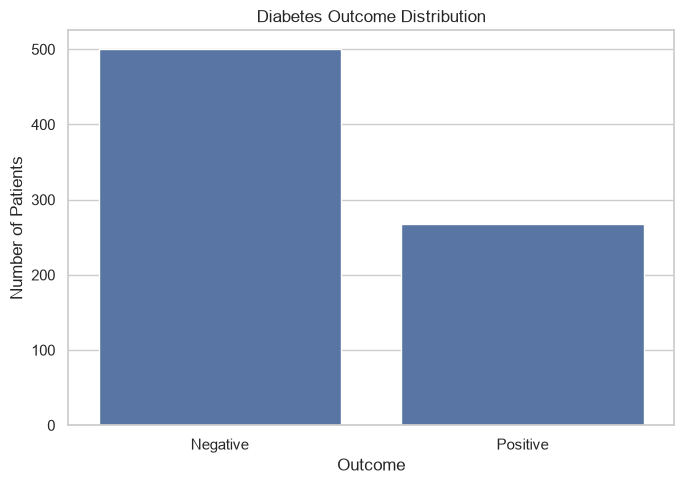

In [9]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="outcome"
)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Negative", "Positive"])

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

### Class Balance

The dataset contains more negative cases than positive cases. Accuracy alone
is therefore insufficient, so precision, recall, F1-score and ROC-AUC are
also evaluated.

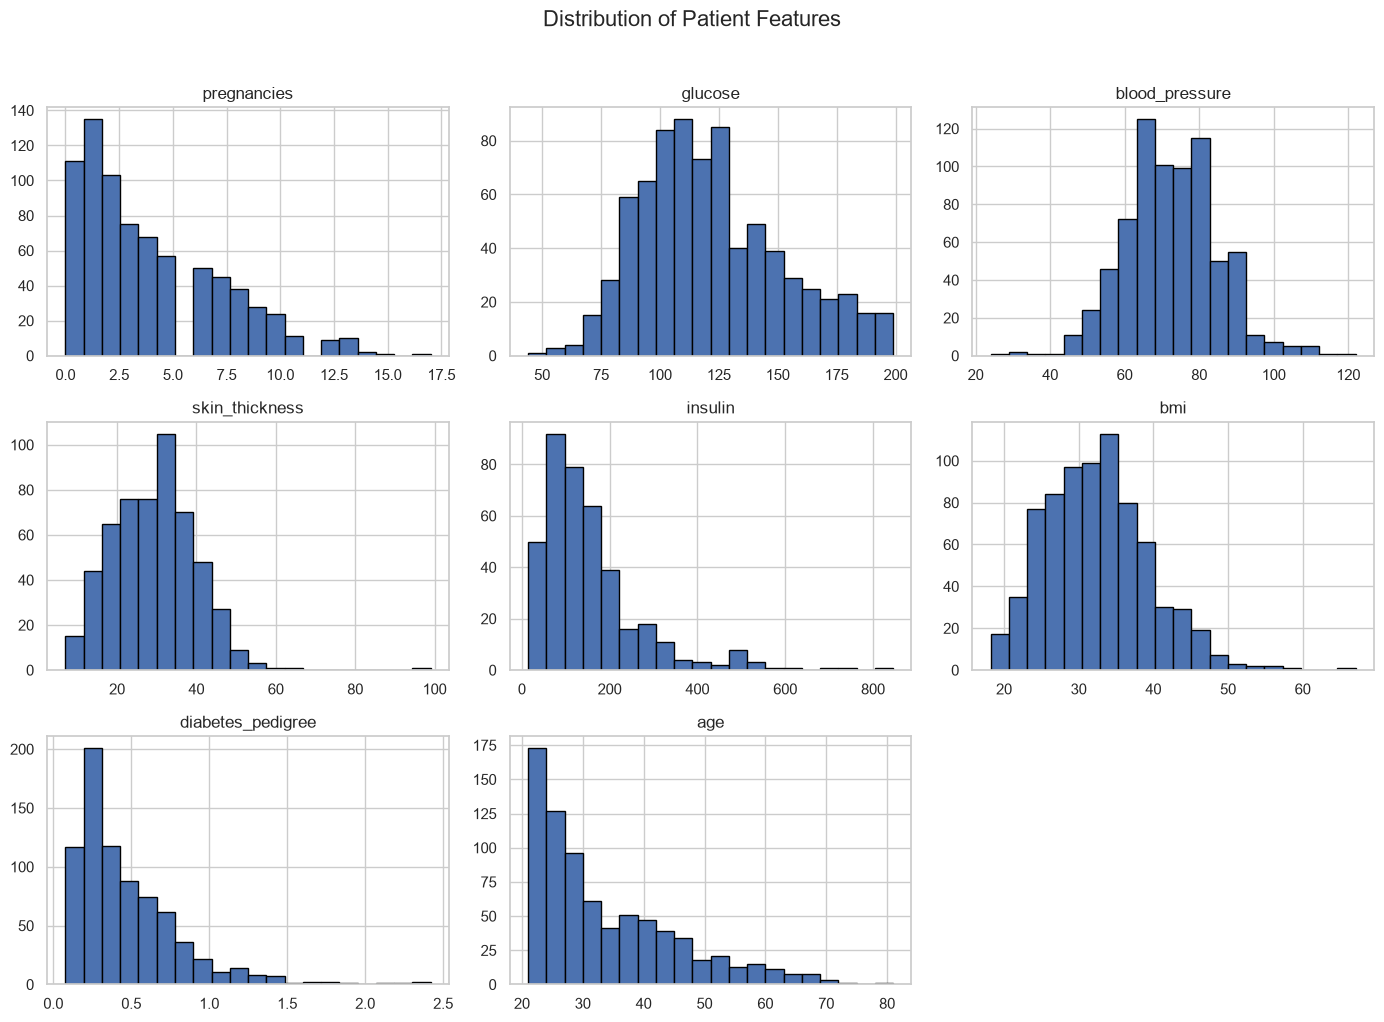

In [10]:
feature_columns = df.drop(columns="outcome").columns

df[feature_columns].hist(
    figsize=(14, 10),
    bins=20,
    edgecolor="black"
)

plt.suptitle(
    "Distribution of Patient Features",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

### Feature Distribution Observations

Some features, particularly insulin and diabetes pedigree values, have
skewed distributions and possible extreme observations.

Median imputation is appropriate because it is less sensitive to extreme
values than mean imputation.

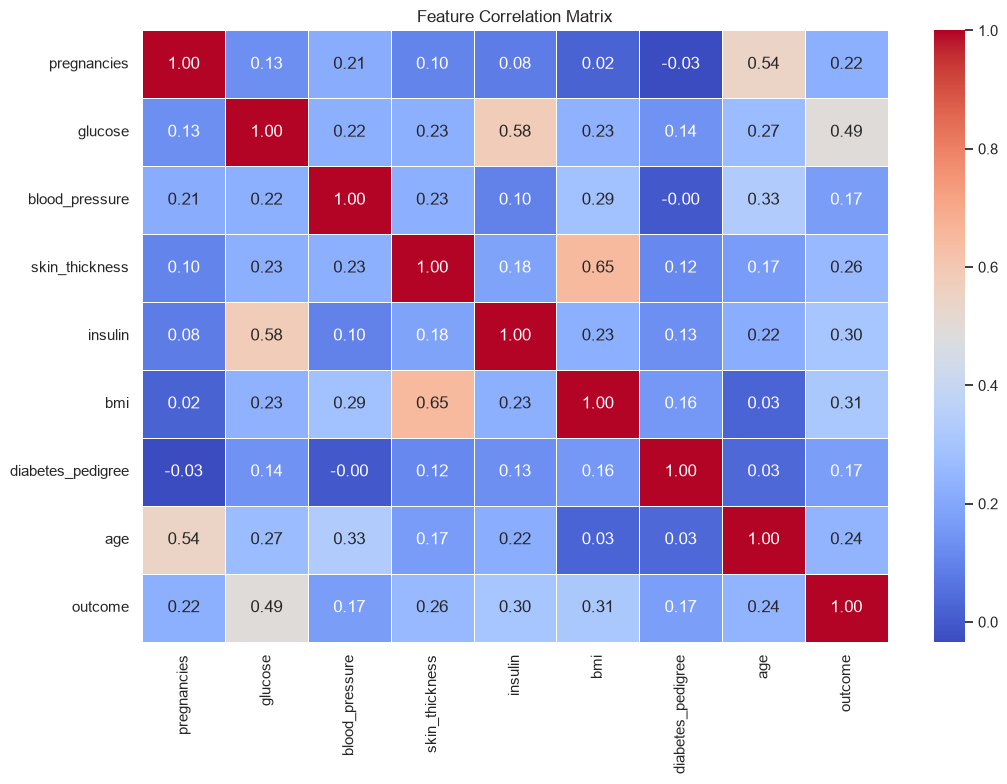

In [11]:
plt.figure(figsize=(11, 8))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

---

<p align="center">
  <img src="assets/IMG1.2.png" width="100%" alt="Diabetes Machine Learning Project Workflow">
</p>

## 6. Machine Learning Workflow

The modelling workflow is designed to keep preprocessing reproducible and
prevent information from the test set from influencing model development.

The main stages are:

1. Separate the clinical features and target.
2. Create a stratified 80:20 train-test split.
3. Replace medically invalid zero values with missing values.
4. Perform median imputation inside each model pipeline.
5. Scale features for Logistic Regression and KNN.
6. Compare four models using five-fold stratified cross-validation.
7. Select the model with the strongest mean cross-validation ROC-AUC.
8. Evaluate the selected model once on the untouched test set.

### 6.1 Feature and Target Separation

The eight clinical input variables are stored in `X`, while the binary
diabetes outcome is stored in `y`.

In [12]:
X = df.drop(columns="outcome")
y = df["outcome"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

Feature matrix shape: (768, 8)
Target vector shape: (768,)

Feature columns:
['pregnancies', 'glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi', 'diabetes_pedigree', 'age']


### 6.2 Stratified Train-Test Split

The dataset is divided into 80% training data and 20% testing data.

Stratification preserves the proportion of positive and negative cases in
both subsets. The test set remains untouched during model comparison.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training features: (614, 8)
Testing features: (154, 8)

Training target distribution:
outcome
0    0.651
1    0.349
Name: proportion, dtype: float64

Testing target distribution:
outcome
0    0.649
1    0.351
Name: proportion, dtype: float64


## 7. Preprocessing and Model Pipelines

Median imputation is included inside every pipeline.

Logistic Regression and KNN also receive standard scaling because they are
sensitive to feature magnitude. Decision Tree and Random Forest do not
require scaling.

In [14]:
scaled_preprocessing_steps = [
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
]

tree_preprocessing_steps = [
    ("imputer", SimpleImputer(strategy="median"))
]

models = {
    "Logistic Regression": Pipeline(
        steps=scaled_preprocessing_steps + [
            (
                "model",
                LogisticRegression(
                    max_iter=1000,
                    random_state=RANDOM_STATE
                )
            )
        ]
    ),

    "KNN": Pipeline(
        steps=scaled_preprocessing_steps + [
            (
                "model",
                KNeighborsClassifier(
                    n_neighbors=5
                )
            )
        ]
    ),

    "Decision Tree": Pipeline(
        steps=tree_preprocessing_steps + [
            (
                "model",
                DecisionTreeClassifier(
                    random_state=RANDOM_STATE
                )
            )
        ]
    ),

    "Random Forest": Pipeline(
        steps=tree_preprocessing_steps + [
            (
                "model",
                RandomForestClassifier(
                    n_estimators=200,
                    random_state=RANDOM_STATE,
                    n_jobs=-1
                )
            )
        ]
    )
}

print("Models created successfully:")

for model_name in models:
    print("-", model_name)

Models created successfully:
- Logistic Regression
- KNN
- Decision Tree
- Random Forest


## 8. Cross-Validation Strategy

Five-fold stratified cross-validation is performed only on the training
data. Each model is evaluated across five different validation folds.

In [15]:
cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring_metrics = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

### Model Evaluation Metrics

| Metric | Purpose |
|---|---|
| Accuracy | Measures overall correct predictions |
| Precision | Measures reliability of positive predictions |
| Recall | Measures detection of actual positive cases |
| F1-score | Balances precision and recall |
| ROC-AUC | Measures ranking ability across thresholds |

ROC-AUC is used as the primary model-selection metric.

In [16]:
cross_validation_results = []

for model_name, model_pipeline in models.items():
    scores = cross_validate(
        estimator=model_pipeline,
        X=X_train,
        y=y_train,
        cv=cross_validation,
        scoring=scoring_metrics,
        n_jobs=-1
    )

    cross_validation_results.append({
        "Model": model_name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1 Score": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

results_df = pd.DataFrame(cross_validation_results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

numeric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

results_df[numeric_columns] = results_df[numeric_columns].round(4)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7882,0.7638,0.5748,0.6545,0.8434
1,Random Forest,0.7720,0.7082,0.6029,0.6495,0.8203
2,KNN,0.7296,0.6367,0.5654,0.5939,0.7843
3,Decision Tree,0.6726,0.5306,0.5795,0.5519,0.6510


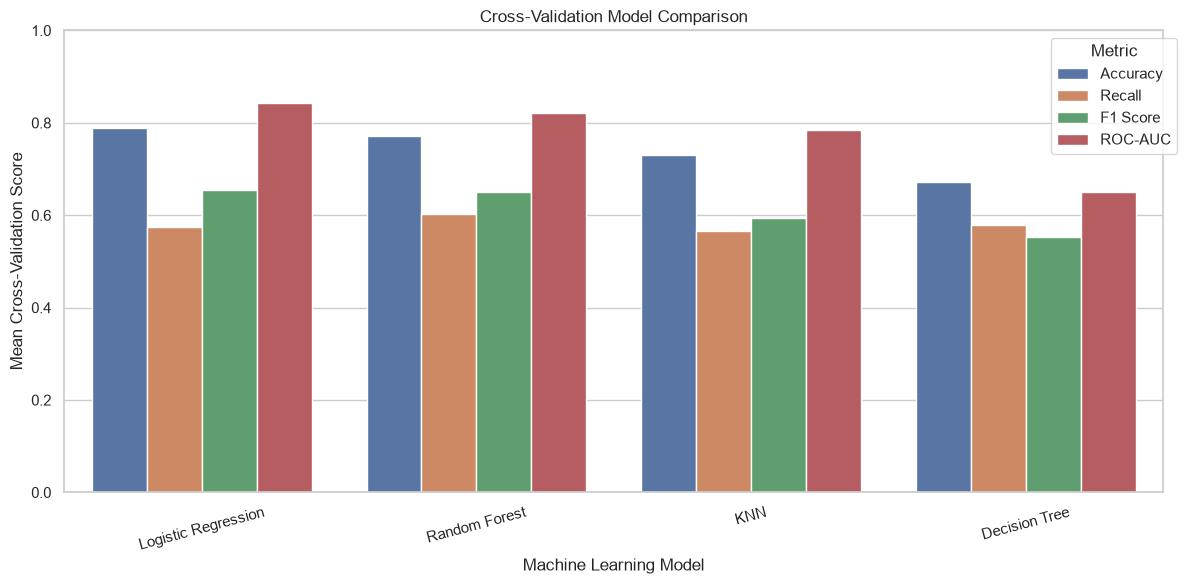

In [17]:
comparison_df = results_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Cross-Validation Model Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Mean Cross-Validation Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

### Model Comparison

Logistic Regression achieved the highest mean cross-validation ROC-AUC and
was selected as the final model.

Random Forest produced slightly stronger recall, but Logistic Regression
showed better overall ranking performance across probability thresholds.

The test set was not used to make this selection.

## 9. Final Model Selection and Training

The model with the highest cross-validation ROC-AUC is selected
automatically, retrained using the full training set and then evaluated on
the untouched test set.

In [18]:
best_model_name = results_df.loc[0, "Model"]
best_model = models[best_model_name]

print("Selected best model:", best_model_name)
print(
    "Cross-validation ROC-AUC:",
    results_df.loc[0, "ROC-AUC"]
)

Selected best model: Logistic Regression
Cross-validation ROC-AUC: 0.8434


In [19]:
best_model.fit(X_train, y_train)

print(
    best_model_name,
    "was successfully trained on the complete training set."
)

Logistic Regression was successfully trained on the complete training set.


In [20]:
y_pred = best_model.predict(X_test)
y_probability = best_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")
print("Number of test predictions:", len(y_pred))

Predictions generated successfully.
Number of test predictions: 154


In [21]:
final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0),
        roc_auc_score(y_test, y_probability)
    ]
})

final_metrics["Score"] = final_metrics["Score"].round(4)

print("Final test results for:", best_model_name)

display(final_metrics)

Final test results for: Logistic Regression


,Metric,Score
0,Accuracy,0.7078
1,Precision,0.6000
2,Recall,0.5000
3,F1 Score,0.5455
4,ROC-AUC,0.8130


---

<p align="center">
  <img src="assets/IMG1.3.png" width="100%" alt="Final Logistic Regression Model Performance">
</p>

## 10. Final Model Evaluation

Logistic Regression was selected because it achieved the highest mean
cross-validation ROC-AUC score.

The final model was trained using the complete training set and evaluated on
the previously untouched test set.

| Metric | Final test score |
|---|---:|
| Accuracy | 70.78% |
| Precision | 60.00% |
| Recall | 50.00% |
| F1-score | 54.55% |
| ROC-AUC | 81.30% |

The ROC-AUC result indicates reasonably good class-separation ability.
However, the positive-class recall of 50% means that the default threshold
detects only half of the actual positive observations.

The following sections examine the classification report, confusion matrix
and ROC curve in greater detail.

### 10.1 Classification Report

The classification report provides separate precision, recall and F1-scores
for negative and positive observations.

Positive-class recall is particularly important because it measures the
percentage of actual positive cases detected by the model.

In [22]:
print(f"Classification Report — {best_model_name}\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Tested Negative",
            "Tested Positive"
        ],
        digits=4,
        zero_division=0
    )
)

Classification Report — Logistic Regression

                 precision    recall  f1-score   support

Tested Negative     0.7523    0.8200    0.7847       100
Tested Positive     0.6000    0.5000    0.5455        54

       accuracy                         0.7078       154
      macro avg     0.6761    0.6600    0.6651       154
   weighted avg     0.6989    0.7078    0.7008       154



### 10.2 Confusion Matrix

The confusion matrix displays true negatives, false positives, false
negatives and true positives.

False negatives are important because they represent positive observations
that the model incorrectly classifies as negative.

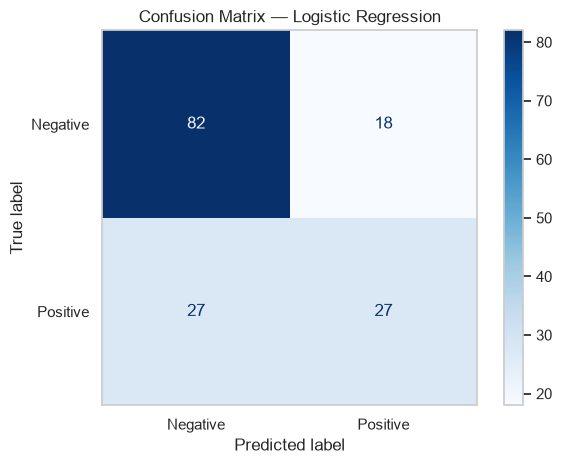

In [23]:
confusion = confusion_matrix(y_test, y_pred)

display_confusion = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=[
        "Negative",
        "Positive"
    ]
)

display_confusion.plot(
    cmap="Blues",
    values_format="d"
)

plt.title(f"Confusion Matrix — {best_model_name}")
plt.grid(False)
plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

The model classifies many negative observations correctly, but it misses a
notable number of positive observations.

This is reflected in the positive-class recall score of 50%.

### 10.3 ROC Curve

The ROC curve shows the relationship between the true-positive rate and
false-positive rate across different classification thresholds.

A curve above the diagonal baseline indicates performance better than random
classification.

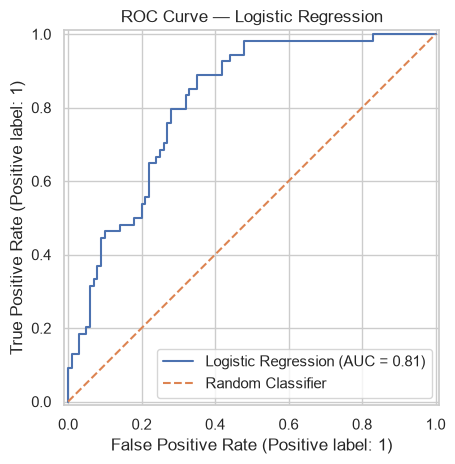

In [24]:
RocCurveDisplay.from_predictions(
    y_test,
    y_probability,
    name=best_model_name
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title(f"ROC Curve — {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Model Interpretation

Permutation feature importance measures the reduction in model performance
when a feature is randomly shuffled.

A larger reduction in ROC-AUC means the trained model relies more heavily on
that feature.

In [25]:
importance_result = permutation_importance(
    estimator=best_model,
    X=X_test,
    y=y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance_result.importances_mean,
    "Importance Standard Deviation": (
        importance_result.importances_std
    )
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

display(feature_importance_df.round(4))

,Feature,Importance,Importance Standard Deviation
0,glucose,0.1683,0.0288
1,bmi,0.0310,0.0140
2,pregnancies,0.0284,0.0114
3,diabetes_pedigree,0.0086,0.0060
4,age,0.0037,0.0036
5,blood_pressure,0.0012,0.0008
6,insulin,0.0006,0.0024
7,skin_thickness,0.0003,0.0011


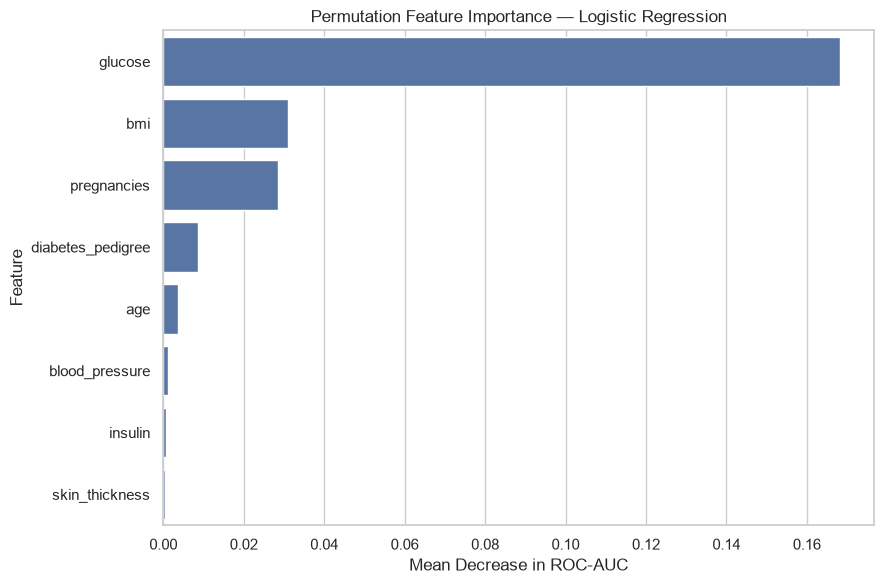

In [26]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=feature_importance_df,
    x="Importance",
    y="Feature"
)

plt.title(
    f"Permutation Feature Importance — {best_model_name}"
)
plt.xlabel("Mean Decrease in ROC-AUC")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Feature Importance Interpretation

The feature-importance results show which clinical variables contribute most
to the trained model's predictions.

These values represent predictive associations and must not be interpreted
as proof that a feature medically causes diabetes.

## 12. Prediction Examples

The following table compares actual and predicted outcomes for selected test
observations. It also displays the model's estimated positive-class
probability.

In [27]:
prediction_results = X_test.copy()

prediction_results["Actual Outcome"] = (
    y_test.map({
        0: "Negative",
        1: "Positive"
    })
)

prediction_results["Predicted Outcome"] = pd.Series(
    y_pred,
    index=X_test.index
).map({
    0: "Negative",
    1: "Positive"
})

prediction_results["Positive Probability"] = (
    y_probability.round(4)
)

display(prediction_results.head(15))


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,age,Actual Outcome,Predicted Outcome,Positive Probability
44,7,159.0,64.0,NaN,NaN,27.4,0.294,40,Negative,Positive,0.6097
672,10,68.0,106.0,23.0,49.0,35.5,0.285,47,Negative,Negative,0.1183
700,2,122.0,76.0,27.0,200.0,35.9,0.483,26,Negative,Negative,0.2934
630,7,114.0,64.0,NaN,NaN,27.4,0.732,34,Positive,Negative,0.2508
81,2,74.0,NaN,NaN,NaN,NaN,0.102,22,Negative,Negative,0.0335
389,3,100.0,68.0,23.0,81.0,31.6,0.949,28,Negative,Negative,0.1685
387,8,105.0,100.0,36.0,NaN,43.3,0.239,45,Positive,Negative,0.4881
408,8,197.0,74.0,NaN,NaN,25.9,1.191,39,Positive,Positive,0.9237
163,2,100.0,64.0,23.0,NaN,29.7,0.368,21,Negative,Negative,0.0814
335,0,165.0,76.0,43.0,255.0,47.9,0.259,26,Negative,Positive,0.8386


### Single-Observation Demonstration

One test observation is passed through the complete trained pipeline.

The pipeline automatically applies median imputation, standard scaling and
Logistic Regression prediction.

In [28]:
sample_patient = X_test.iloc[[0]].copy()

sample_prediction = best_model.predict(sample_patient)[0]
sample_probability = best_model.predict_proba(
    sample_patient
)[0, 1]

print("Sample patient information:")
display(sample_patient)

print(
    "Predicted outcome:",
    "Positive" if sample_prediction == 1 else "Negative"
)

print(
    f"Predicted positive probability: "
    f"{sample_probability:.2%}"
)

print(
    "Actual outcome:",
    "Positive" if y_test.loc[sample_patient.index[0]] == 1
    else "Negative"
)

Sample patient information:


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,age
44,7,159.0,64.0,NaN,NaN,27.4,0.294,40


Predicted outcome: Positive
Predicted positive probability: 60.97%
Actual outcome: Negative


## 13. Model Persistence

The complete trained pipeline is saved with `joblib`.

Saving the full pipeline preserves both preprocessing and prediction logic,
allowing future observations to be processed consistently.

In [29]:
import joblib

model_filename = "diabetes_prediction_model.joblib"

joblib.dump(best_model, model_filename)

print("Model saved as:", model_filename)

Model saved as: diabetes_prediction_model.joblib


In [30]:
loaded_model = joblib.load(
    "diabetes_prediction_model.joblib"
)

loaded_prediction = loaded_model.predict(
    X_test.iloc[[0]]
)[0]

print(
    "Loaded model prediction:",
    "Positive" if loaded_prediction == 1 else "Negative"
)

Loaded model prediction: Positive


In [31]:
best_test_results = dict(
    zip(
        final_metrics["Metric"],
        final_metrics["Score"]
    )
)

print("=" * 60)
print("DIABETES PREDICTION PROJECT SUMMARY")
print("=" * 60)

print(f"Dataset size: {df.shape[0]} rows")
print(f"Number of features: {X.shape[1]}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Selected model: {best_model_name}")

print("\nFinal Test Metrics")

for metric_name, metric_score in best_test_results.items():
    print(f"{metric_name}: {metric_score:.4f}")

print("\nImportant note:")
print(
    "This project is intended only for educational machine-learning "
    "demonstration. It is not a medical diagnostic system."
)

DIABETES PREDICTION PROJECT SUMMARY
Dataset size: 768 rows
Number of features: 8
Training samples: 614
Testing samples: 154
Selected model: Logistic Regression

Final Test Metrics
Accuracy: 0.7078
Precision: 0.6000
Recall: 0.5000
F1 Score: 0.5455
ROC-AUC: 0.8130

Important note:
This project is intended only for educational machine-learning demonstration. It is not a medical diagnostic system.


---

## 14. Conclusion

This project developed a leakage-safe machine learning workflow for diabetes
outcome classification.

Four models were compared using five-fold stratified cross-validation.
Logistic Regression achieved the highest mean cross-validation ROC-AUC and
was selected as the final model.

On the unseen test set, it achieved:

- **Accuracy:** 70.78%
- **Precision:** 60.00%
- **Recall:** 50.00%
- **F1-score:** 54.55%
- **ROC-AUC:** 81.30%

The model demonstrated useful overall class-separation ability, but the
positive-class recall indicates that the default classification threshold
misses several positive observations.

### Limitations

- The dataset contains only 768 observations.
- Several measurements originally used zero to represent missing data.
- The represented population is limited.
- The results may not generalize to other populations.
- Feature importance indicates association rather than causation.
- The default probability threshold may not be optimal.

### Future Improvements

- Class-weighted Logistic Regression
- Probability-threshold tuning
- Hyperparameter optimization
- Repeated stratified cross-validation
- Precision-recall curve analysis
- Probability calibration
- SHAP-based explanations
- Deployment through a web interface

> This notebook is an educational machine learning project and must not be
> used as a medical diagnostic system.